# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
  *A linear model is one that has linear parameters and also a straight line equation where the slope remains constant and variables are summed together.*
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
*With an intercept the intercept will absorb the mean of the dropped category or reference group. The dummy is the difference between the mean and y for that reference group. Without an intercept every mean is the coefficient for that group.*
3. Can linear regression be used for classification? Explain why, or why not.
*Typically it is not because it produces predicted values outside [0,1] and assumes normal distributed errors that arent true. Logistic regression is better for classification*
4. What are signs that your linear model is over-fitting?
*A large gap between training and test and CV performance, very large or wrongly-signed coefficients, and high variance across cross-validation folds*
5. Clearly explain multi-colinearity using the two-stage least squares technique.
*This is when regressors are so correlated that one stage least squares can't separate their effects so the two stage fixes this by regressing the variable on an instrument to isolate the orthogonal variation, then using that version in the outcome regression (second stage)*
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
*Linearity only requires that the parameters are added so you can very easily transform versions of x that are polynomials or logarithms and introduce them as new columns.*
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?
*The intercept is the y value output when all predictors are 0. The slope coefficient is the expected change in y for every step change in x. And the dummy coefficient is the expected difference in y between a group and the reference group where the mean is the intercept*

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Q1_clean.csv to Q1_clean.csv


In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("Q1_clean.csv")

In [14]:
df = df.rename(columns={
    "Review Scores Rating": "review_score",
    "Neighbourhood ": "neighbourhood",  # watch trailing space
    "Property Type": "property_type",
    "Room Type": "room_type",
    "Price per night": "price"
})

In [15]:
df.head()
print(df.shape)
df.value_counts()

(22153, 5)


Price  review_score  neighbourhood  property_type  room_type      
200    100.0         Manhattan      Apartment      Entire home/apt    125
150    100.0         Manhattan      Apartment      Entire home/apt    117
250    100.0         Manhattan      Apartment      Entire home/apt    103
150    100.0         Brooklyn       Apartment      Entire home/apt     97
125    100.0         Brooklyn       Apartment      Entire home/apt     73
                                                                     ... 
1500   99.0          Brooklyn       Loft           Entire home/apt      1
       97.0          Brooklyn       Loft           Entire home/apt      1
       96.0          Manhattan      House          Entire home/apt      1
1499   100.0         Brooklyn       Loft           Entire home/apt      1
1495   93.0          Manhattan      Apartment      Entire home/apt      1
Name: count, Length: 8872, dtype: int64

In [16]:
grouped = df.groupby("neighbourhood")[["Price", "review_score"]].mean()
print(grouped.sort_values("Price", ascending=False))

                    Price  review_score
neighbourhood                          
Manhattan      183.664286     91.801496
Staten Island  146.166667     90.843750
Brooklyn       127.747378     92.363497
Queens          96.857233     91.549057
Bronx           75.276498     91.654378


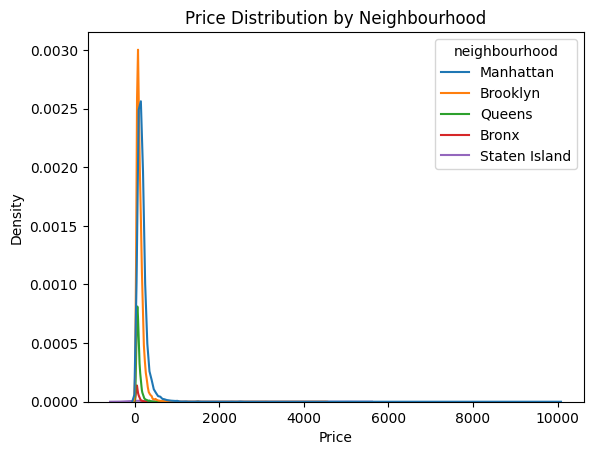

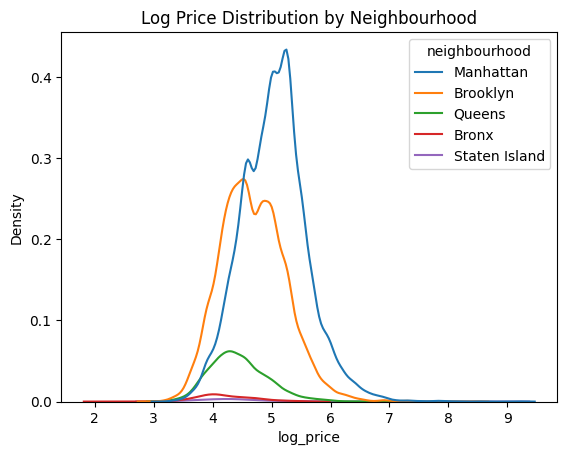

In [19]:
sns.kdeplot(data=df, x="Price", hue="neighbourhood")
plt.title("Price Distribution by Neighbourhood")
plt.show()


df["log_price"] = np.log(df["Price"])

sns.kdeplot(data=df, x="log_price", hue="neighbourhood")
plt.title("Log Price Distribution by Neighbourhood")
plt.show()

In [21]:
#with intercept removed, used help from onlines sources
X = pd.get_dummies(df["neighbourhood"], drop_first=False)
y = df["Price"]
import statsmodels.api as sm

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        15:05:40   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Bronx            75.2765      9.868      7.628

In [24]:
#With intercept, used help
X = pd.get_dummies(df["neighbourhood"], drop_first=True)
X = sm.add_constant(X)


In [29]:
X = X.astype(float)
y = y.astype(float)

In [30]:
modelint = sm.OLS(y, X).fit()
print(modelint.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        15:10:45   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

train, test = train_test_split(df, test_size=0.2, random_state=42)

In [34]:
X_train = pd.get_dummies(train[["review_score", "neighbourhood"]], drop_first=True)
X_test = pd.get_dummies(test[["review_score", "neighbourhood"]], drop_first=True)

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

y_train = train["Price"]
y_test = test["Price"]

X_train = X_train.astype(float)
y_train = y_train.astype(float)

model2 = sm.OLS(y_train, X_train).fit()
print(model2.summary())

preds = model2.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = model2.rsquared
print(r2)
print(rmse)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     189.8
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          1.33e-197
Time:                        15:12:53   Log-Likelihood:            -1.1348e+05
No. Observations:               17722   AIC:                         2.270e+05
Df Residuals:                   17716   BIC:                         2.270e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

The largest neighborhood coefficient and intercept is the most expensive property


In [38]:
X_train = pd.get_dummies(train[["review_score", "neighbourhood", "property_type"]], drop_first=True)
X_test = pd.get_dummies(test[["review_score", "neighbourhood", "property_type"]], drop_first=True)

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

X_train = X_train.astype(float)
y_train = y_train.astype(float)

model3 = sm.OLS(y_train, X_train).fit()

rmse2 = np.sqrt(mean_squared_error(y_test, preds))
r2_2 = model3.rsquared
print(rmse2)
print(r2_2)

140.91821103729345
0.06012308879068373


The r2 increased and the rmse stayed the same. A change in property type explains a change in price variation.

In [40]:
#The review score coefficient changes due to omitted variable biases.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving cars_hw.csv to cars_hw.csv


In [41]:
#step 1 is cleaning
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("cars_hw.csv")
df = df.drop(columns=["Unnamed: 0"])
df["log_price"] = np.log(df["Price"])
df = df[df["Price"] < df["Price"].quantile(0.99)]

In [42]:
df.head()
print(df.shape)
df.value_counts()

(966, 12)


Make     Make_Year  Color  Body_Type  Mileage_Run  No_of_Owners  Seating_Capacity  Fuel_Type  Transmission  Transmission_Type  Price    log_price
Ford     2019       red    hatchback  45590        1st           5                 diesel     5-Speed       Manual             644000   13.375454    4
         2020       grey   hatchback  11762        1st           5                 diesel     5-Speed       Manual             787000   13.575984    4
Hyundai  2016       blue   suv        97039        1st           5                 diesel     6-Speed       Manual             1086000  13.898012    4
                    grey   suv        88735        2nd           5                 diesel     6-Speed       Manual             1099000  13.909911    4
         2017       grey   sedan      45378        1st           5                 petrol     5-Speed       Manual             589000   13.286181    4
                                                                                                                                                    ..
         2018       brown  sedan      35623        2nd           5                 petrol     6-Speed       Automatic          963000   13.777809    1
                                      87773        1st           5                 diesel     6-Speed       Automatic          937000   13.750439    1
                    grey   hatchback  16760        1st           5                 petrol     5-Speed       Manual             522000   13.165423    1
                                      28557        2nd           5                 petrol     5-Speed       Automatic          574000   13.260385    1
         2017       white  sedan      60287        1st           5                 petrol     4-Speed       Automatic          837000   13.637579    1
Name: count, Length: 886, dtype: int64

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.